# EDA — NSL-KDD Dataset
Exploratory Data Analysis on the KDD Train/Test dataset before model building.

> **Updated** to include pipeline-alignment sections (§3b, §10–12) that verify
> the SMOTE distribution, scaling correctness, split sizes, and processed-feature
> correlations — keeping the EDA in sync with `02_preprocessing.ipynb` and `03_model_training.ipynb`.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)

## 1. Load & Label Data

In [6]:
cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'KDDTrain+.txt'), names=cols)
test  = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'KDDTest+.txt'),  names=cols)

train.drop('difficulty', axis=1, inplace=True)
test.drop('difficulty',  axis=1, inplace=True)

label_map = {
    'normal': 'Normal',
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'xlock':'R2L','xsnoop':'R2L','worm':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'httptunnel':'U2R','ps':'U2R','sqlattack':'U2R','xterm':'U2R'
}

train['label'] = train['label'].map(label_map)
test['label']  = test['label'].map(label_map)

print('Train:', train.shape, '  Test:', test.shape)
train.head(3)

Train: (125973, 42)   Test: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,DoS


## 2. Missing Values

In [7]:
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values — clean dataset!')

No missing values — clean dataset!


## 3. Class Distribution

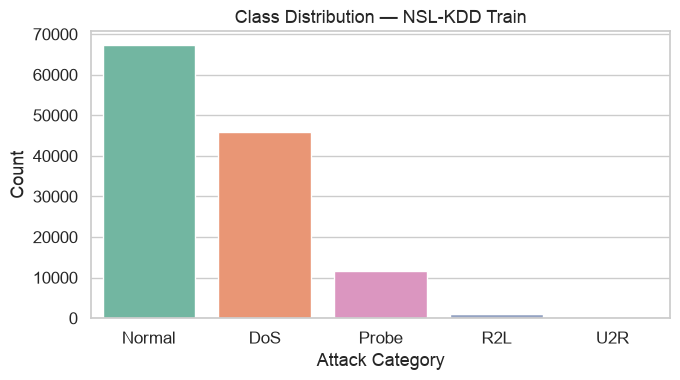

        Count  Percent
label                 
Normal  67343    53.46
DoS     45927    36.46
Probe   11656     9.25
R2L       995     0.79
U2R        52     0.04


In [8]:
order = train['label'].value_counts().index

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=train, x='label', order=order, hue='label', palette='Set2', legend=False, ax=ax)
ax.set_title('Class Distribution — NSL-KDD Train')
ax.set_xlabel('Attack Category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

dist = train['label'].value_counts()
pct  = dist / dist.sum() * 100
print(pd.DataFrame({'Count': dist, 'Percent': pct.round(2)}))

## 3b. Class Distribution — Post-SMOTE (pipeline-aligned)

> The raw distribution above shows the heavy skew towards DoS and Normal.
> After SMOTE is applied in `02_preprocessing.ipynb`, minority classes
> (R2L, U2R, Probe) are oversampled so the model trains on a balanced set.
> This cell loads the saved `y_train.npy` to show the **exact distribution
> the XGBoost model trains on**.

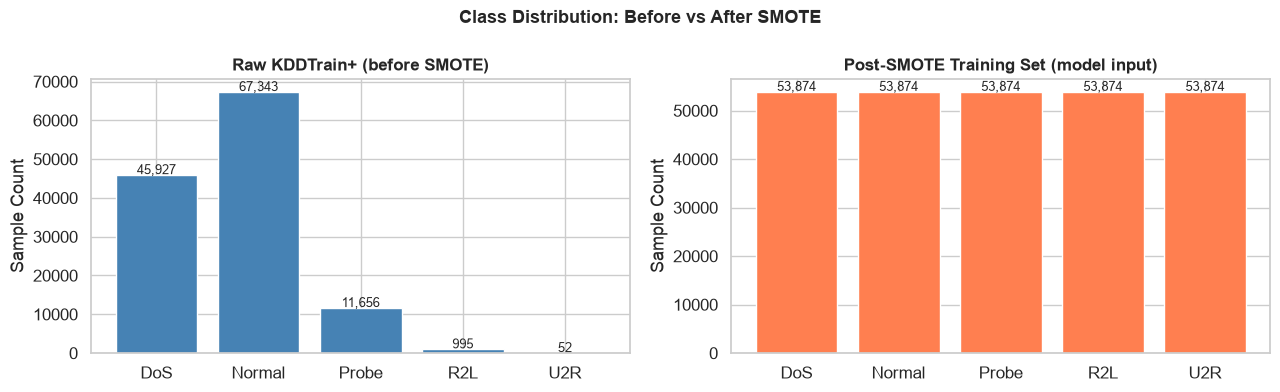

Post-SMOTE distribution:
  DoS          53,874
  Normal       53,874
  Probe        53,874
  R2L          53,874
  U2R          53,874


In [9]:
BASE_DIR      = os.path.dirname(os.getcwd())
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

import joblib
from collections import Counter

y_train_smote  = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
target_encoder = joblib.load(os.path.join(PROCESSED_DIR, 'target_encoder.pkl'))
CLASS_NAMES    = list(target_encoder.classes_)   # ['DoS','Normal','Probe','R2L','U2R']

counts_raw    = train['label'].value_counts().reindex(CLASS_NAMES, fill_value=0)
counts_smote  = Counter(y_train_smote)
counts_smote_labeled = {CLASS_NAMES[k]: v for k, v in counts_smote.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw
axes[0].bar(counts_raw.index, counts_raw.values, color='steelblue', edgecolor='white')
axes[0].set_title('Raw KDDTrain+ (before SMOTE)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sample Count')
for i, v in enumerate(counts_raw.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Post-SMOTE
smote_vals = [counts_smote_labeled.get(c, 0) for c in CLASS_NAMES]
bars = axes[1].bar(CLASS_NAMES, smote_vals, color='coral', edgecolor='white')
axes[1].set_title('Post-SMOTE Training Set (model input)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sample Count')
for i, v in enumerate(smote_vals):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Post-SMOTE distribution:')
for cls, cnt in zip(CLASS_NAMES, smote_vals):
    print(f'  {cls:<10} {cnt:>8,}')

## 4. Categorical Features

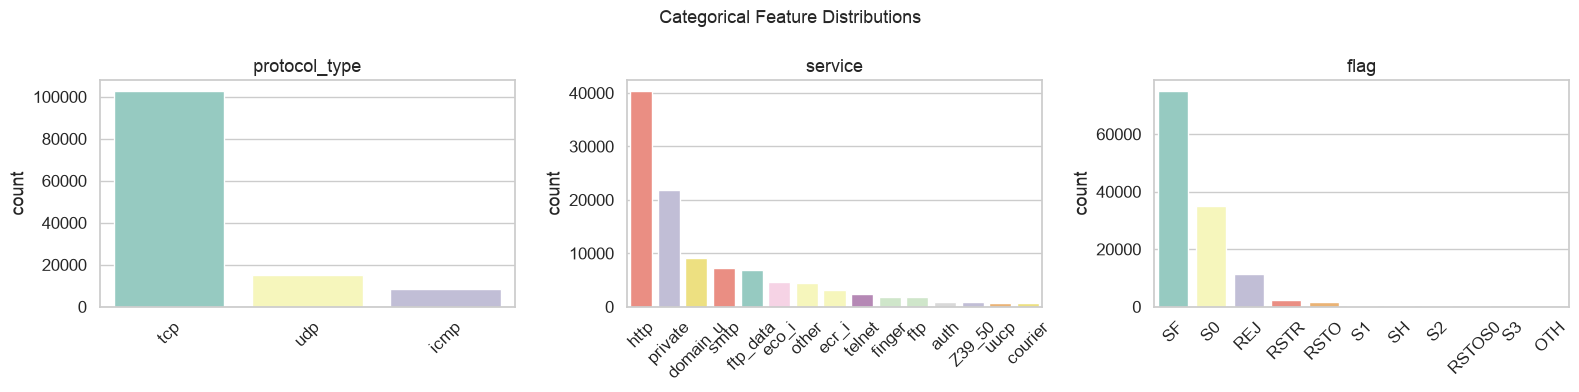

In [10]:
cat_cols = ['protocol_type', 'service', 'flag']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    order = train[col].value_counts().index[:15]
    sns.countplot(data=train, x=col, order=order, hue=col, palette='Set3', legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Numeric Feature Distributions

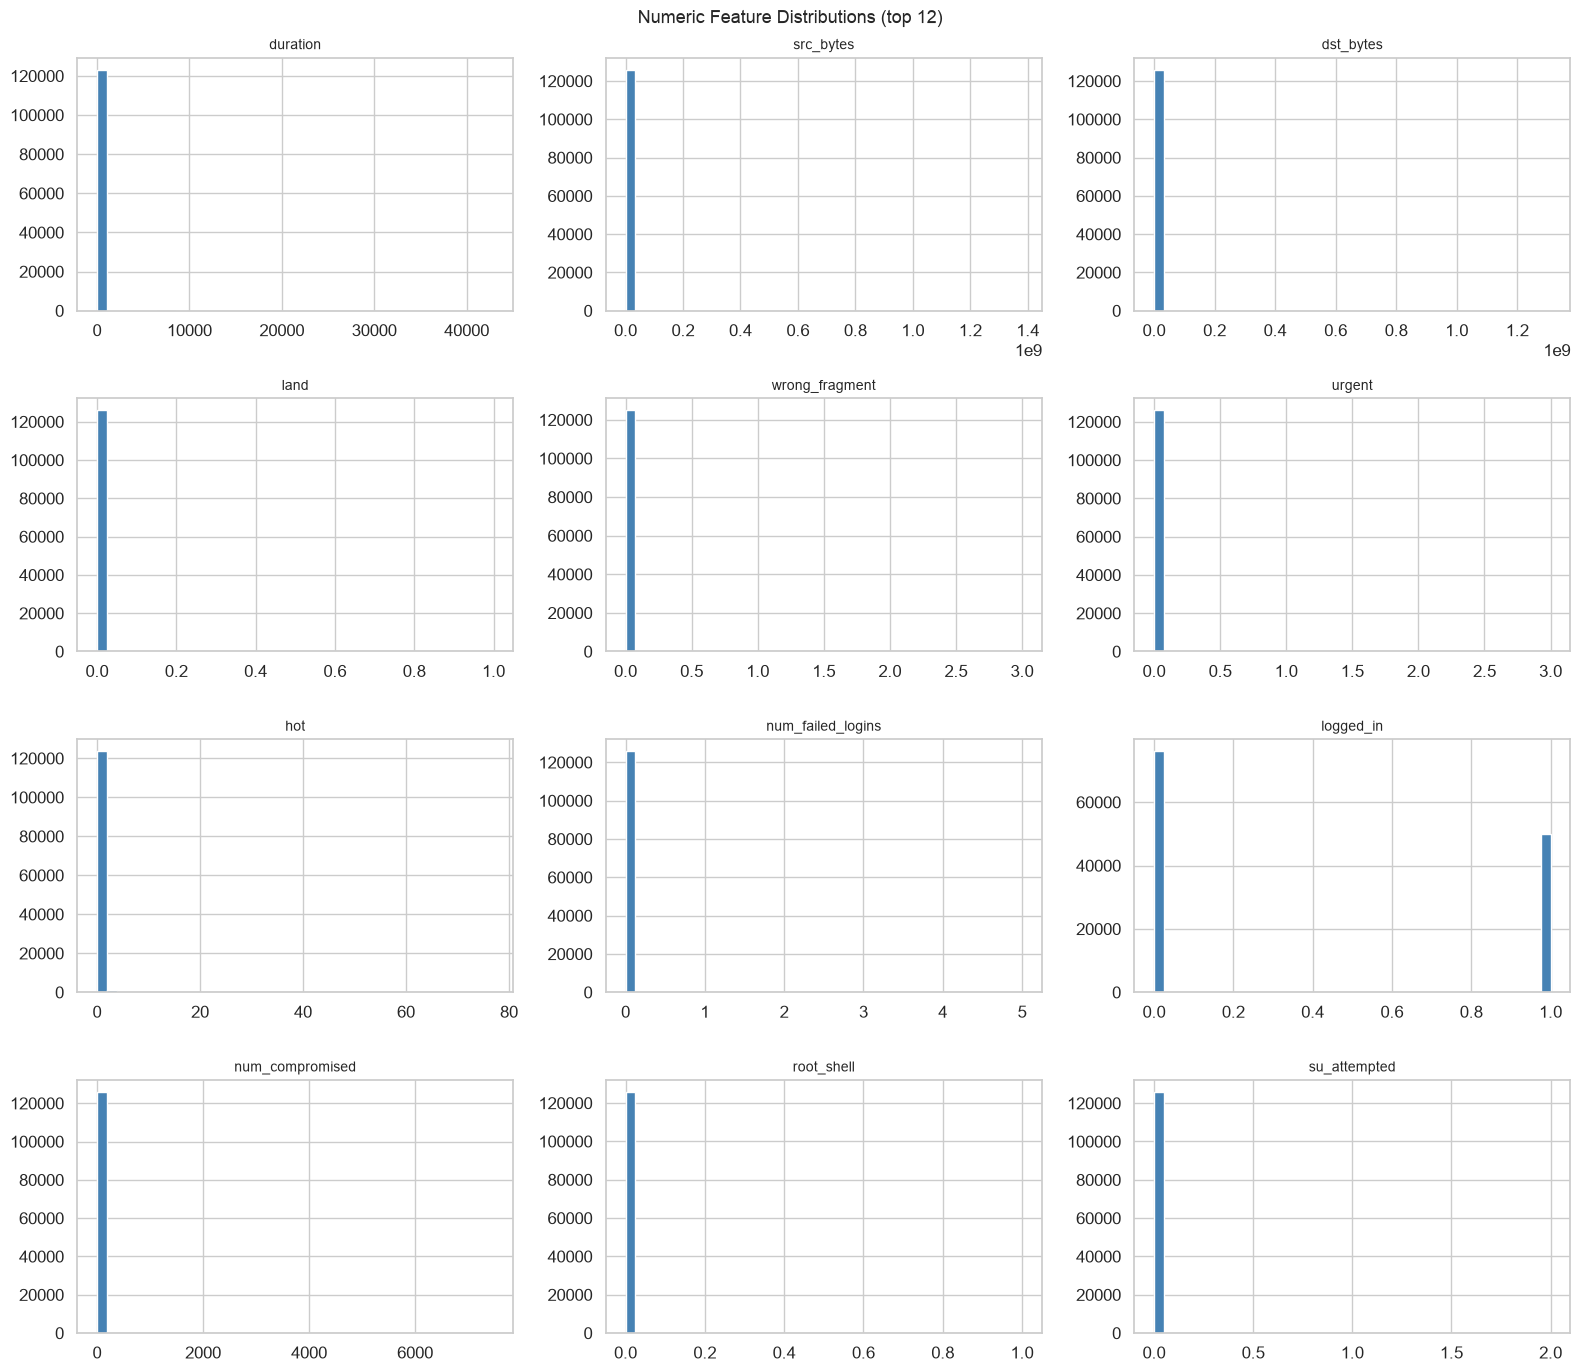

In [11]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), num_cols[:12]):
    train[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Numeric Feature Distributions (top 12)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap (raw features)

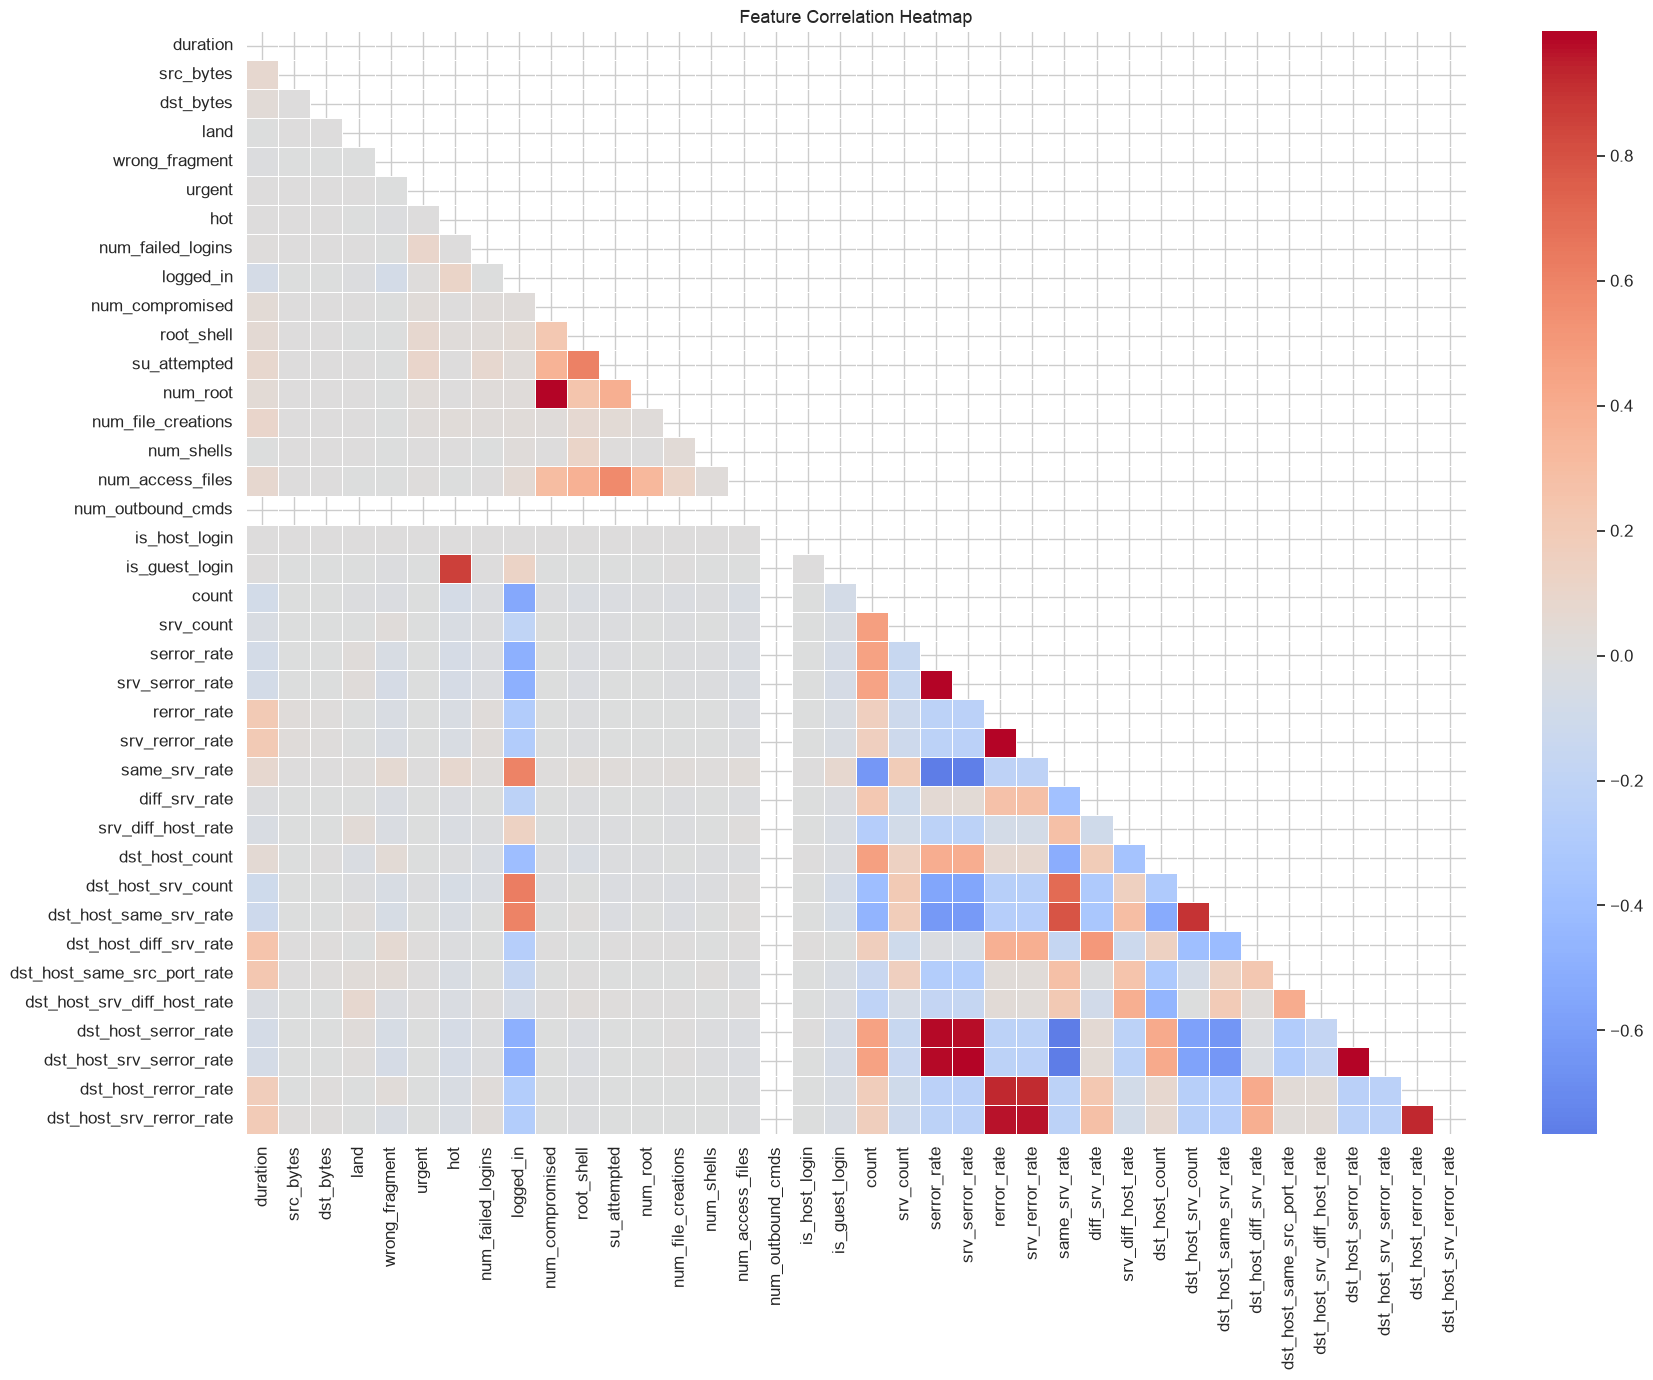

In [12]:
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.4, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. Key Features by Attack Category

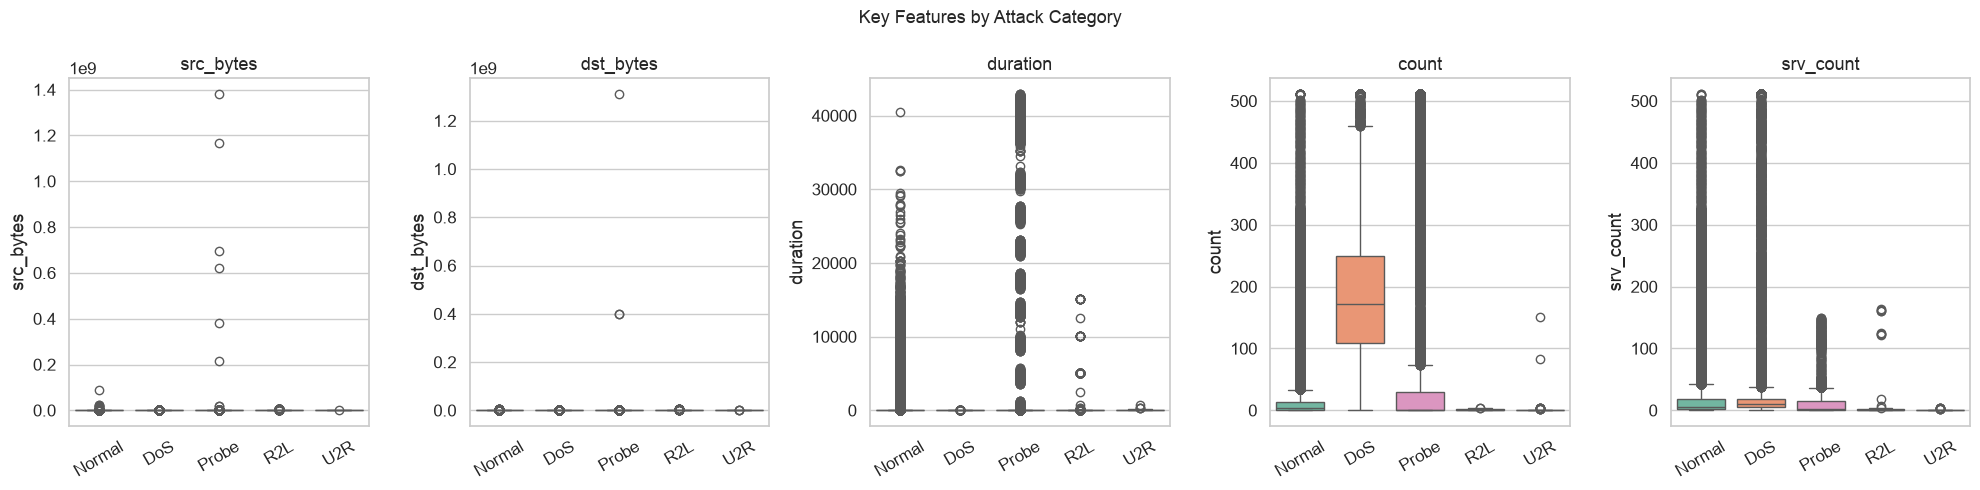

In [13]:
key_features = ['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']
order = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

fig, axes = plt.subplots(1, len(key_features), figsize=(20, 5))
for ax, feat in zip(axes, key_features):
    sns.boxplot(data=train, x='label', y=feat, order=order,
                hue='label', palette='Set2', legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Key Features by Attack Category', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Protocol vs Attack Category

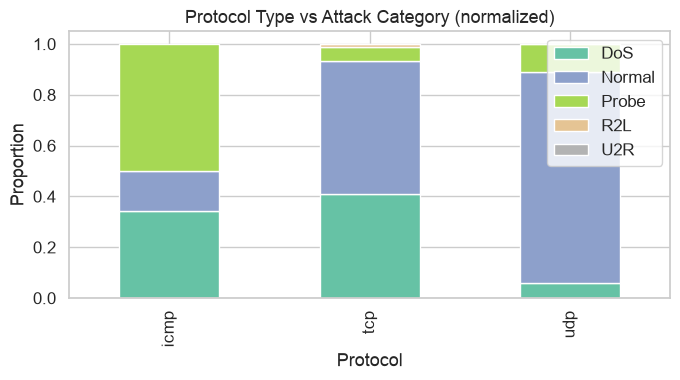

In [14]:
ct = pd.crosstab(train['protocol_type'], train['label'])
ct.div(ct.sum(axis=1), axis=0).plot(kind='bar', stacked=True, colormap='Set2', figsize=(7, 4))
plt.title('Protocol Type vs Attack Category (normalized)')
plt.xlabel('Protocol')
plt.ylabel('Proportion')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. Summary Stats per Class

In [15]:
train.groupby('label')[['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']].mean().round(2)

,src_bytes,dst_bytes,duration,count,srv_count
label,,,,,
DoS,1176.32,169.20,0.01,178.09,32.66
Normal,13133.28,4329.69,168.59,22.52,27.69
Probe,385679.84,181074.91,2074.86,77.05,10.94
R2L,307727.30,81822.03,633.42,1.30,2.46
U2R,906.23,5141.96,80.94,5.81,1.27


## 10. Feature Scaling Verification (pipeline-aligned)

> After `StandardScaler` is applied in `02_preprocessing.ipynb`, every feature
> should have approximately **zero mean** and **unit standard deviation**.
> This cell confirms the scaler worked correctly on the training set, and shows
> the scaled distribution of a sample feature — useful for catching any leakage
> (e.g. if the scaler was accidentally fit on val/test data too).

Post-scaling statistics (should be ≈ mean=0.0, std=1.0):
  Global mean-of-means : 0.00000
  Global mean-of-stds  : 1.00000
  Max |mean|           : 0.00000  (feature: num_file_creations)
  Min std              : 1.00000  (feature: su_attempted)
  Shape                : (269370, 40)


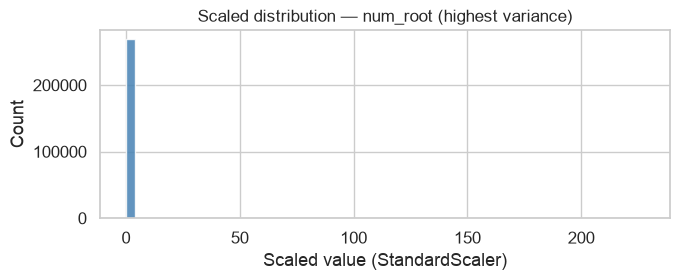

In [16]:
PROCESSED_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed')
import joblib

X_train       = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
feature_names = joblib.load(os.path.join(PROCESSED_DIR, 'feature_names.pkl'))

per_feature_means = X_train.mean(axis=0)
per_feature_stds  = X_train.std(axis=0)

print('Post-scaling statistics (should be ≈ mean=0.0, std=1.0):')
print(f'  Global mean-of-means : {per_feature_means.mean():.5f}')
print(f'  Global mean-of-stds  : {per_feature_stds.mean():.5f}')
print(f'  Max |mean|           : {np.abs(per_feature_means).max():.5f}  (feature: {feature_names[np.abs(per_feature_means).argmax()]})')
print(f'  Min std              : {per_feature_stds.min():.5f}  (feature: {feature_names[per_feature_stds.argmin()]})')
print(f'  Shape                : {X_train.shape}')

# Distribution plot for the highest-variance feature
top_var_idx = per_feature_stds.argmax()
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(X_train[:, top_var_idx], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title(f'Scaled distribution — {feature_names[top_var_idx]} (highest variance)', fontsize=12)
ax.set_xlabel('Scaled value (StandardScaler)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 11. Train / Val / Test Split Summary (pipeline-aligned)

> Documents the exact split sizes produced by `02_preprocessing.ipynb`
> so the EDA reflects what the model actually sees — including the SMOTE
> expansion on the training fold.

In [17]:
PROCESSED_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed')

X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

import joblib
target_encoder = joblib.load(os.path.join(PROCESSED_DIR, 'target_encoder.pkl'))
CLASS_NAMES    = list(target_encoder.classes_)
feature_names  = joblib.load(os.path.join(PROCESSED_DIR, 'feature_names.pkl'))

total = len(X_train) + len(X_val) + len(X_test)
print('━' * 52)
print('  Split Summary')
print('━' * 52)
print(f'  Train (post-SMOTE)  : {len(X_train):>8,}  rows  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation          : {len(X_val):>8,}  rows  ({len(X_val)/total*100:.1f}%)')
print(f'  Test  (KDDTest+)    : {len(X_test):>8,}  rows  ({len(X_test)/total*100:.1f}%)')
print(f'  Total               : {total:>8,}  rows')
print(f'  Features            : {X_train.shape[1]}')
print(f'  Classes             : {CLASS_NAMES}')
print('━' * 52)

# Per-class breakdown in val and test sets
import pandas as pd
from collections import Counter

def class_table(y, name):
    counts = Counter(y)
    rows   = {CLASS_NAMES[k]: counts.get(k, 0) for k in sorted(counts)}
    return pd.Series(rows, name=name)

tbl = pd.concat([
    class_table(y_val,  'Val count'),
    class_table(y_test, 'Test count'),
], axis=1)
tbl['Val %']  = (tbl['Val count']  / tbl['Val count'].sum()  * 100).round(1)
tbl['Test %'] = (tbl['Test count'] / tbl['Test count'].sum() * 100).round(1)
print('\nPer-class breakdown:')
print(tbl.to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Split Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train (post-SMOTE)  :  269,370  rows  (84.9%)
  Validation          :   25,195  rows  (7.9%)
  Test  (KDDTest+)    :   22,544  rows  (7.1%)
  Total               :  317,109  rows
  Features            : 40
  Classes             : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Per-class breakdown:
        Val count  Test count  Val %  Test %
DoS          9186        7458   36.5    33.1
Normal      13469        9711   53.5    43.1
Probe        2331        2421    9.3    10.7
R2L           199        2754    0.8    12.2
U2R            10         200    0.0     0.9


## 12. Correlation Heatmap — Processed Features (pipeline-aligned)

> Section 6 above shows raw-feature correlations.
> This section shows correlations **after StandardScaler** on the actual
> training features used by the model — filtered to the top 20 by variance
> for readability.  
> High correlations here are candidates for further feature selection if
> model generalisation remains a concern.

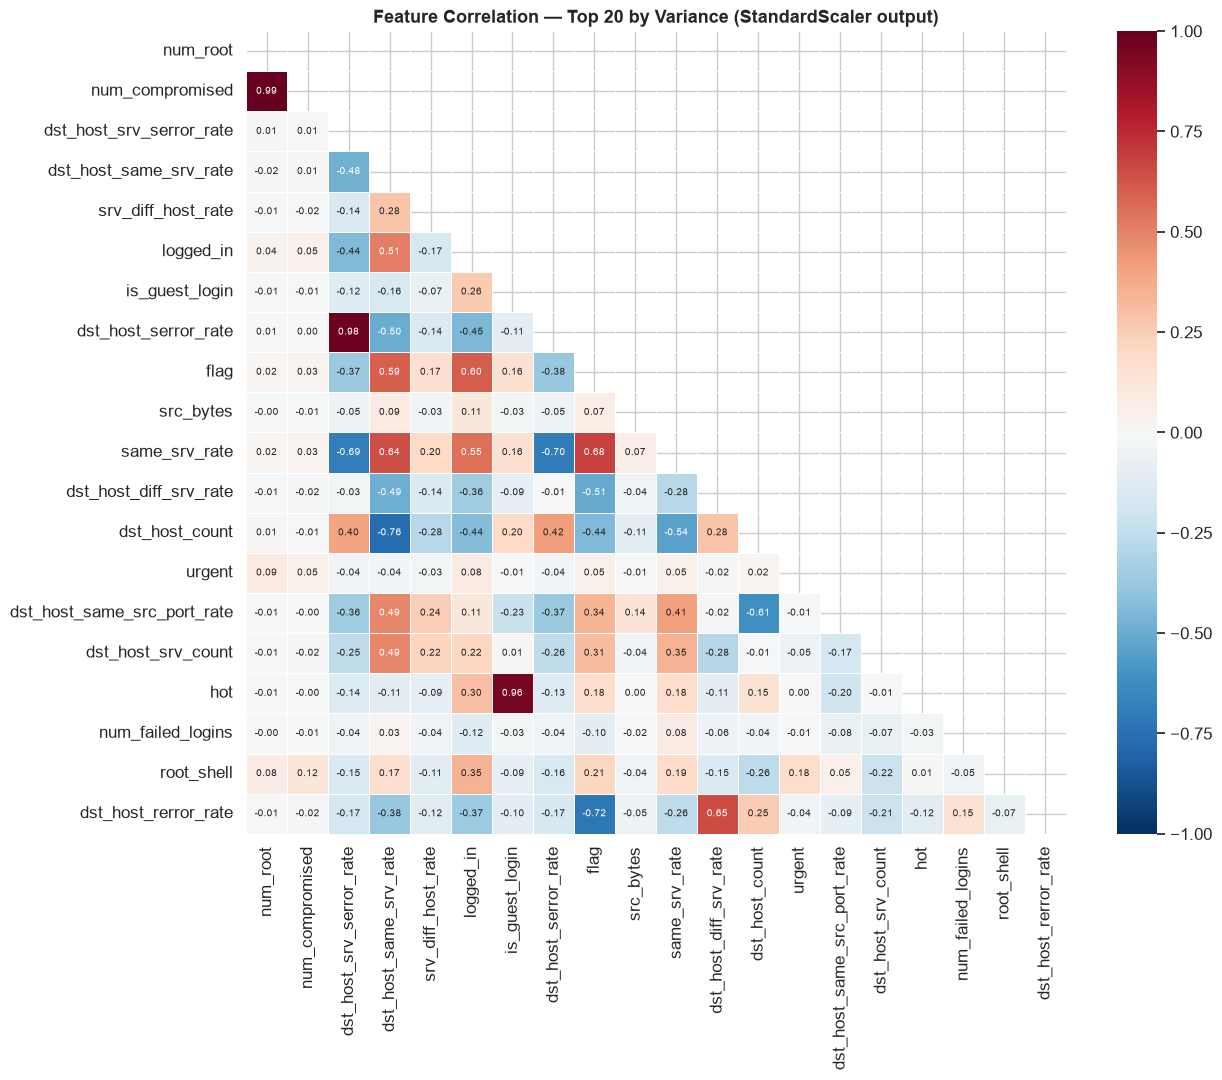


Highly correlated pairs (|r| > 0.90) — candidates for removal:
  num_compromised                     ↔  num_root                             r=0.994
  dst_host_serror_rate                ↔  dst_host_srv_serror_rate             r=0.98
  hot                                 ↔  is_guest_login                       r=0.957


In [18]:
PROCESSED_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed')
import joblib, numpy as np, matplotlib.pyplot as plt, seaborn as sns

X_train       = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
feature_names = joblib.load(os.path.join(PROCESSED_DIR, 'feature_names.pkl'))

# Top 20 features by variance in the processed set
variances  = X_train.var(axis=0)
top20_idx  = np.argsort(variances)[::-1][:20]
names_top20 = [feature_names[i] for i in top20_idx]

# Subsample for speed (5k rows is plenty for correlation)
rng     = np.random.default_rng(42)
idx     = rng.choice(len(X_train), size=min(5000, len(X_train)), replace=False)
import pandas as pd
corr_df = pd.DataFrame(X_train[idx][:, top20_idx], columns=names_top20).corr()

mask = np.triu(np.ones_like(corr_df, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation — Top 20 by Variance (StandardScaler output)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.90)
corr_abs = corr_df.abs()
high_corr = [
    (corr_df.columns[i], corr_df.columns[j], round(corr_df.iloc[i, j], 3))
    for i in range(len(corr_df))
    for j in range(i)
    if corr_abs.iloc[i, j] > 0.90
]
if high_corr:
    print(f'\nHighly correlated pairs (|r| > 0.90) — candidates for removal:')
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {a:35s} ↔  {b:35s}  r={r}')
else:
    print('No pairs with |r| > 0.90 in top-20 processed features.')